In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer

import os
from scipy.sparse import coo_matrix

In [3]:
#Read dataset
tr_data=pd.read_csv('marketing_sample_for_walmart_com-walmart_com_product_review__20200701_20201231__5k_data.tsv',sep='\t')
tr_data.columns

Index(['Uniq Id', 'Crawl Timestamp', 'Dataset Origin', 'Product Id',
       'Product Barcode', 'Product Company Type Source',
       'Product Brand Source', 'Product Brand Normalised Source',
       'Product Name Source', 'Match Rank', 'Match Score', 'Match Type',
       'Retailer', 'Product Category', 'Product Brand', 'Product Name',
       'Product Price', 'Sku', 'Upc', 'Product Url', 'Market',
       'Product Description', 'Product Currency',
       'Product Available Inventory', 'Product Image Url',
       'Product Model Number', 'Product Tags', 'Product Contents',
       'Product Rating', 'Product Reviews Count', 'Bsr', 'Joining Key'],
      dtype='object')

In [4]:
tr_data.head()

,Uniq Id,Crawl Timestamp,Dataset Origin,Product Id,Product Barcode,Product Company Type Source,Product Brand Source,Product Brand Normalised Source,Product Name Source,Match Rank,...,Product Currency,Product Available Inventory,Product Image Url,Product Model Number,Product Tags,Product Contents,Product Rating,Product Reviews Count,Bsr,Joining Key
0,1705736792d82aa2f2d3caf1c07c53f4,2020-09-24 03:21:12 +0000,NaN,2e17bf4acecdece67fc00f07ad62c910,NaN,Competitor,NaN,NaN,NaN,NaN,...,USD,111111111,https://i5.walmartimages.com/asr/0e1f4c51-c1a4...,NaN,"OPI Infinite Shine, Nail Lacquer Nail Polish, ...",NaN,NaN,NaN,NaN,81350af1be98d3753cf964709f0c766a
1,95a9fe6f4810fcfc7ff244fd06784f11,2020-10-30 14:04:08 +0000,NaN,076e5854a62dd283c253d6bae415af1f,NaN,Competitor,NaN,NaN,NaN,NaN,...,USD,111111111,https://i5.walmartimages.com/asr/9c8e42e4-13a5...,NaN,"Nice 'n Easy Permanent Color, 111 Natural Medi...",NaN,NaN,NaN,NaN,0353e63907dc0de0c734db4690300057
2,8d4d0330178d3ed181b15a4102b287f2,2020-08-06 05:51:47 +0000,NaN,8a4fe5d9c7a6ed26cc44d785a454b124,NaN,Competitor,NaN,NaN,NaN,NaN,...,USD,111111111,https://i5.walmartimages.com/asr/e3a601c2-6a2b...,NaN,Clairol Nice 'N Easy Permanent Color 7/106A Na...,NaN,4.5,29221.0,NaN,b6985c8e94815fbca2319dbb8bf228af
3,fddc4df45b35efd886794b261f730c51,2020-07-15 11:22:04 +0000,NaN,03b5fb878a33eadff8b033419eab9669,NaN,Competitor,NaN,NaN,NaN,NaN,...,USD,111111111,https://i5.walmartimages.com/asr/25b4b467-bc61...,NaN,"Kokie Professional Matte Lipstick, Hot Berry, ...",NaN,NaN,NaN,NaN,85b70fded09186f00467cea2f935b779
4,0990cf89a59ca6a0460349a3e4f51d42,2020-11-26T12:27:20+00:00,NaN,ce3d761e57d6ccad80619297b5b1bcbc,NaN,Competitor,NaN,NaN,NaN,NaN,...,USD,111111111,https://i5.walmartimages.com/asr/1a2ebb06-cd01...,NaN,"Gillette TRAC II Plus Razor Blade Refills, Fit...",NaN,NaN,131.0,NaN,41c870871328e97da6fb036bb7d4b2da


In [5]:
#perform some operations
tr_data['Product Category']

0       Premium Beauty > Premium Makeup > Premium Nail...
1       Beauty > Hair Care > Hair Color > Auburn Hair ...
2       Beauty > Hair Care > Hair Color > Permanent Ha...
3                                   Beauty > Makeup > Lip
4       Seasonal > Stock Up Essentials > Personal Care...
                              ...                        
4995    Household Essentials > Air Fresheners > Spray ...
4996    Beauty > Hair Care > Hair Color > Permanent Ha...
4997                              Beauty > Makeup > Nails
4998    Premium Beauty > Premium Bath & Body > Premium...
4999    Beauty > Makeup > Face Makeup > Face Makeup Br...
Name: Product Category, Length: 5000, dtype: object

In [6]:
tr_data.shape

(5000, 32)

In [7]:
#check null values
tr_data.isnull().sum()

Uniq Id                               0
Crawl Timestamp                       0
Dataset Origin                     5000
Product Id                            0
Product Barcode                    5000
Product Company Type Source           0
Product Brand Source               4861
Product Brand Normalised Source    4861
Product Name Source                4861
Match Rank                         5000
Match Score                        5000
Match Type                         5000
Retailer                              0
Product Category                     10
Product Brand                        13
Product Name                          0
Product Price                        42
Sku                                5000
Upc                                5000
Product Url                           0
Market                                0
Product Description                1127
Product Currency                      0
Product Available Inventory           0
Product Image Url                     0


In [8]:
tr_data['Product Reviews Count']

0           NaN
1           NaN
2       29221.0
3           NaN
4         131.0
         ...   
4995        2.0
4996     7484.0
4997        4.0
4998        NaN
4999      438.0
Name: Product Reviews Count, Length: 5000, dtype: float64

In [9]:
tr_data['Market']

0       US
1       US
2       US
3       US
4       US
        ..
4995    US
4996    US
4997    US
4998    US
4999    US
Name: Market, Length: 5000, dtype: object

In [10]:
#let us filter useful columns
tr_data=tr_data[['Uniq Id','Product Id','Product Name','Product Rating','Product Reviews Count','Product Category','Product Brand','Product Image Url','Product Description','Product Tags']]
tr_data.head()

,Uniq Id,Product Id,Product Name,Product Rating,Product Reviews Count,Product Category,Product Brand,Product Image Url,Product Description,Product Tags
0,1705736792d82aa2f2d3caf1c07c53f4,2e17bf4acecdece67fc00f07ad62c910,"OPI Infinite Shine, Nail Lacquer Nail Polish, ...",NaN,NaN,Premium Beauty > Premium Makeup > Premium Nail...,OPI,https://i5.walmartimages.com/asr/0e1f4c51-c1a4...,NaN,"OPI Infinite Shine, Nail Lacquer Nail Polish, ..."
1,95a9fe6f4810fcfc7ff244fd06784f11,076e5854a62dd283c253d6bae415af1f,"Nice n Easy Permanent Color, 111 Natural Mediu...",NaN,NaN,Beauty > Hair Care > Hair Color > Auburn Hair ...,Nice'n Easy,https://i5.walmartimages.com/asr/9c8e42e4-13a5...,Pack of 3 Pack of 3 for the UPC: 381519000201 ...,"Nice 'n Easy Permanent Color, 111 Natural Medi..."
2,8d4d0330178d3ed181b15a4102b287f2,8a4fe5d9c7a6ed26cc44d785a454b124,Clairol Nice N Easy Permanent Color 7/106A Nat...,4.5,29221.0,Beauty > Hair Care > Hair Color > Permanent Ha...,Clairol,https://i5.walmartimages.com/asr/e3a601c2-6a2b...,This Clairol Nice N Easy Permanent Color gives...,Clairol Nice 'N Easy Permanent Color 7/106A Na...
3,fddc4df45b35efd886794b261f730c51,03b5fb878a33eadff8b033419eab9669,"Kokie Professional Matte Lipstick, Hot Berry, ...",NaN,NaN,Beauty > Makeup > Lip,Kokie Cosmetics,https://i5.walmartimages.com/asr/25b4b467-bc61...,Calling all matte lip lovers! Indulge in our r...,"Kokie Professional Matte Lipstick, Hot Berry, ..."
4,0990cf89a59ca6a0460349a3e4f51d42,ce3d761e57d6ccad80619297b5b1bcbc,"Gillette TRAC II Plus Razor Blade Refills, Fit...",NaN,131.0,Seasonal > Stock Up Essentials > Personal Care...,Gillette,https://i5.walmartimages.com/asr/1a2ebb06-cd01...,"In 1971, Gillette introduced the Trac II razor...","Gillette TRAC II Plus Razor Blade Refills, Fit..."


In [11]:
tr_data.isnull().sum()

Uniq Id                     0
Product Id                  0
Product Name                0
Product Rating           2806
Product Reviews Count    1654
Product Category           10
Product Brand              13
Product Image Url           0
Product Description      1127
Product Tags                0
dtype: int64

In [12]:
#we need to fill the null values

In [13]:
tr_data['Product Rating'].fillna(0,inplace=True) 
tr_data['Product Reviews Count'].fillna(0,inplace = True)
tr_data['Product Category'].fillna(0,inplace=True)
tr_data['Product Brand'].fillna('',inplace=True)
tr_data['Product Description'].fillna('',inplace=True)
# now run the isnull().sum() cell again


C:\Users\SRIVALLI\AppData\Local\Temp\ipykernel_155948\3482424636.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  tr_data['Product Rating'].fillna(0,inplace=True)
C:\Users\SRIVALLI\AppData\Local\Temp\ipykernel_155948\3482424636.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.


In [14]:
tr_data.isnull().sum()

Uniq Id                  0
Product Id               0
Product Name             0
Product Rating           0
Product Reviews Count    0
Product Category         0
Product Brand            0
Product Image Url        0
Product Description      0
Product Tags             0
dtype: int64

In [15]:
#now let us check duplicates
tr_data.duplicated().sum()

np.int64(0)

In [16]:
#let us change the column names
column_name_mapping = {
    'Uniq Id': 'Id',
    'Product Id': 'ProdId',
    'Product Rating':'Rating',
    'Product Reviews Count': 'ReviewCount',
    'Product Category':'Category',
    'Product Name': 'Name',
    'Product Image Url':'ImageUrl',
    'Product Description': 'Description',
    'Product Tags':'Tags',
    'Product Contents':'Contents',
    'Product Brand':'Brand'
}

In [17]:
# now rename the columns using rename method (we are assigning new names to the cols)
tr_data.rename(columns=column_name_mapping,inplace=True)

In [18]:
tr_data

,Id,ProdId,Name,Rating,ReviewCount,Category,Brand,ImageUrl,Description,Tags
0,1705736792d82aa2f2d3caf1c07c53f4,2e17bf4acecdece67fc00f07ad62c910,"OPI Infinite Shine, Nail Lacquer Nail Polish, ...",0.0,0.0,Premium Beauty > Premium Makeup > Premium Nail...,OPI,https://i5.walmartimages.com/asr/0e1f4c51-c1a4...,,"OPI Infinite Shine, Nail Lacquer Nail Polish, ..."
1,95a9fe6f4810fcfc7ff244fd06784f11,076e5854a62dd283c253d6bae415af1f,"Nice n Easy Permanent Color, 111 Natural Mediu...",0.0,0.0,Beauty > Hair Care > Hair Color > Auburn Hair ...,Nice'n Easy,https://i5.walmartimages.com/asr/9c8e42e4-13a5...,Pack of 3 Pack of 3 for the UPC: 381519000201 ...,"Nice 'n Easy Permanent Color, 111 Natural Medi..."
2,8d4d0330178d3ed181b15a4102b287f2,8a4fe5d9c7a6ed26cc44d785a454b124,Clairol Nice N Easy Permanent Color 7/106A Nat...,4.5,29221.0,Beauty > Hair Care > Hair Color > Permanent Ha...,Clairol,https://i5.walmartimages.com/asr/e3a601c2-6a2b...,This Clairol Nice N Easy Permanent Color gives...,Clairol Nice 'N Easy Permanent Color 7/106A Na...
3,fddc4df45b35efd886794b261f730c51,03b5fb878a33eadff8b033419eab9669,"Kokie Professional Matte Lipstick, Hot Berry, ...",0.0,0.0,Beauty > Makeup > Lip,Kokie Cosmetics,https://i5.walmartimages.com/asr/25b4b467-bc61...,Calling all matte lip lovers! Indulge in our r...,"Kokie Professional Matte Lipstick, Hot Berry, ..."
4,0990cf89a59ca6a0460349a3e4f51d42,ce3d761e57d6ccad80619297b5b1bcbc,"Gillette TRAC II Plus Razor Blade Refills, Fit...",0.0,131.0,Seasonal > Stock Up Essentials > Personal Care...,Gillette,https://i5.walmartimages.com/asr/1a2ebb06-cd01...,"In 1971, Gillette introduced the Trac II razor...","Gillette TRAC II Plus Razor Blade Refills, Fit..."
...,...,...,...,...,...,...,...,...,...,...
4995,2771f0606e9638de508741f52029d51c,ad208aa8da338e84dfcf13efd49e8a75,"Garden Mint Room Spray (Double Strength), 4 ou...",4.5,2.0,Household Essentials > Air Fresheners > Spray ...,Eclectic Lady,https://i5.walmartimages.com/asr/0e0416ae-6b70...,"Garden Mint is a lovely blend of spearmint, le...","Garden Mint Room Spray (Double Strength), 4 ou..."
4996,0f218eb3ac736975ccfdde987baa4b83,1be8241fd6249f7ee007b06afd7ff45d,Garnier Nutrisse Nourishing Hair Color Creme (...,3.9,7484.0,Beauty > Hair Care > Hair Color > Permanent Ha...,Garnier,https://i5.walmartimages.com/asr/24d7a837-51f8...,Garnier Nutrisse Nourishing Hair Color Creme B...,Garnier Nutrisse Nourishing Hair Color Creme (...
4997,34d1aa70845416c3df059a088aaf18dc,96ed378fb9466b11abde8f9baea58844,"Nail File Electric Drill, 6 in 1 Professional ...",0.0,4.0,Beauty > Makeup > Nails,Stoneway,https://i5.walmartimages.com/asr/d6202179-2c93...,Multifunctional : Our nail drill kit come with...,"Nail File Electric Drill, 6 in 1 Professional ..."
4998,ff9cfa22550bf036e2487a9100d927f1,f7b05869f3ee7fe22864ea58cbb006d1,Creed Love In Black Hair And Body Wash 6.8oz/2...,0.0,0.0,Premium Beauty > Premium Bath & Body > Premium...,Creed,https://i5.walmartimages.com/asr/3dc99239-66d2...,,Creed Love In Black Hair And Body Wash 6.8oz/2...


In [19]:
#since the id and the prodId should be in integer type we are going to change it

tr_data['Id']=tr_data['Id'].str.extract(r'(\d+)').astype(float)

In [20]:
#similarly to prodId
tr_data['ProdId']=tr_data['ProdId'].str.extract(r'(\d+)').astype(float)

STEP 2: EDA

In [21]:
#stats

users=tr_data['Id'].nunique()
items=tr_data['ProdId'].nunique()
ratings = tr_data['Rating'].nunique()
print("number of unique users:",users)
print("number of unique items:",items)
print("number of unique ratings:",ratings)

number of unique users: 1721
number of unique items: 1697
number of unique ratings: 36


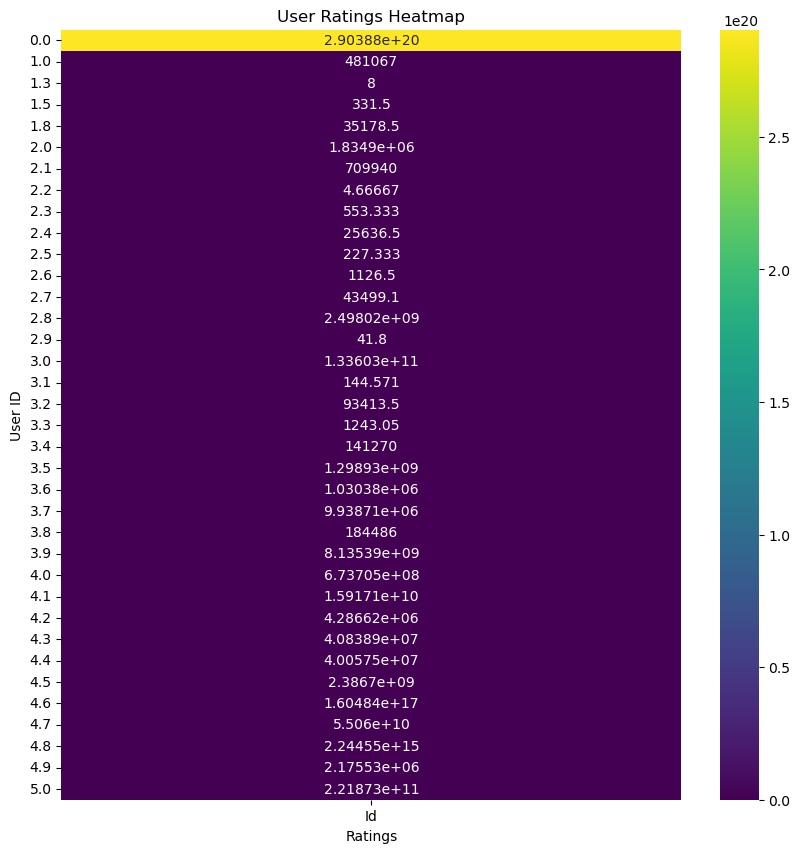

In [22]:
heatmap_data=tr_data.pivot_table('Id','Rating')

#let us create the heatmap 
plt.figure(figsize=(10,10))
sns.heatmap(heatmap_data,annot=True,fmt='g',cmap='viridis',cbar=True)
plt.title('User Ratings Heatmap')
plt.xlabel('Ratings')
plt.ylabel('User ID')
plt.show()

Text(0.5, 1.0, 'Most Rating Products')

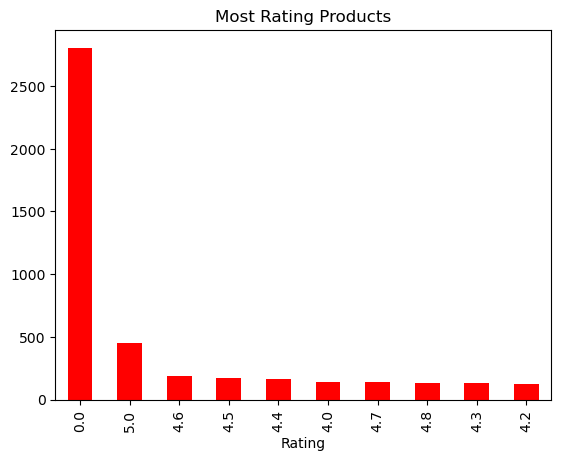

In [23]:
#most rated counts:
most_ratings=tr_data['Rating'].value_counts().head(10)
most_ratings.plot(kind='bar',color='red')
plt.title("Most Rating Products")

In [24]:
# the above graph reps top 10 ratings on X-axis and their count on the Y-axis

Text(0.5, 1.0, 'Popular Items')

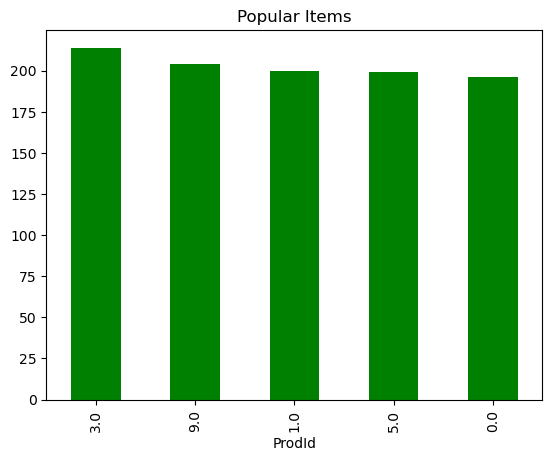

In [25]:
#let us see popular items
pop_items=tr_data['ProdId'].value_counts().head()  #it gives top 5 popular products
pop_items.plot(kind='bar',color='green')
plt.title("Popular Items")


In [26]:
# pip install spacy  

In [27]:
# !python -m spacy download en_core_web_sm

In [28]:
import spacy
from spacy.lang.en.stop_words import STOP_WORDS  #it is an nlp library

nlp = spacy.load("en_core_web_sm")

def clean_and_extract_tags(text):
    text=str(text)
    doc = nlp(text.lower())
    tags = [token.text for token in doc if token.text.isalnum() and token.text not in STOP_WORDS]
    return ','.join(tags)

columns_to_extract_tags = ['Category','Brand','Description']

for col in columns_to_extract_tags:
    tr_data[col] = tr_data[col].apply(clean_and_extract_tags)

In [29]:
tr_data

,Id,ProdId,Name,Rating,ReviewCount,Category,Brand,ImageUrl,Description,Tags
0,1.705737e+09,2.0,"OPI Infinite Shine, Nail Lacquer Nail Polish, ...",0.0,0.0,"premium,beauty,premium,makeup,premium,nail,pol...",opi,https://i5.walmartimages.com/asr/0e1f4c51-c1a4...,,"OPI Infinite Shine, Nail Lacquer Nail Polish, ..."
1,9.500000e+01,76.0,"Nice n Easy Permanent Color, 111 Natural Mediu...",0.0,0.0,"beauty,hair,care,hair,color,auburn,hair,color",easy,https://i5.walmartimages.com/asr/9c8e42e4-13a5...,"pack,3,pack,3,upc,381519000201,beautiful,natur...","Nice 'n Easy Permanent Color, 111 Natural Medi..."
2,8.000000e+00,8.0,Clairol Nice N Easy Permanent Color 7/106A Nat...,4.5,29221.0,"beauty,hair,care,hair,color,permanent,hair,color",clairol,https://i5.walmartimages.com/asr/e3a601c2-6a2b...,"clairol,nice,n,easy,permanent,color,gives,8,we...",Clairol Nice 'N Easy Permanent Color 7/106A Na...
3,4.000000e+00,3.0,"Kokie Professional Matte Lipstick, Hot Berry, ...",0.0,0.0,"beauty,makeup,lip","kokie,cosmetics",https://i5.walmartimages.com/asr/25b4b467-bc61...,"calling,matte,lip,lovers,indulge,rich,creamy,m...","Kokie Professional Matte Lipstick, Hot Berry, ..."
4,9.900000e+02,3.0,"Gillette TRAC II Plus Razor Blade Refills, Fit...",0.0,131.0,"seasonal,stock,essentials,personal,care,stock,...",gillette,https://i5.walmartimages.com/asr/1a2ebb06-cd01...,"1971,gillette,introduced,trac,ii,razor,system,...","Gillette TRAC II Plus Razor Blade Refills, Fit..."
...,...,...,...,...,...,...,...,...,...,...
4995,2.771000e+03,208.0,"Garden Mint Room Spray (Double Strength), 4 ou...",4.5,2.0,"household,essentials,air,fresheners,spray,air,...","eclectic,lady",https://i5.walmartimages.com/asr/0e0416ae-6b70...,"garden,mint,lovely,blend,spearmint,lettuce,rai...","Garden Mint Room Spray (Double Strength), 4 ou..."
4996,0.000000e+00,1.0,Garnier Nutrisse Nourishing Hair Color Creme (...,3.9,7484.0,"beauty,hair,care,hair,color,permanent,hair,color",garnier,https://i5.walmartimages.com/asr/24d7a837-51f8...,"garnier,nutrisse,nourishing,hair,color,creme,b...",Garnier Nutrisse Nourishing Hair Color Creme (...
4997,3.400000e+01,96.0,"Nail File Electric Drill, 6 in 1 Professional ...",0.0,4.0,"beauty,makeup,nails",stoneway,https://i5.walmartimages.com/asr/d6202179-2c93...,"multifunctional,nail,drill,kit,come,6,differen...","Nail File Electric Drill, 6 in 1 Professional ..."
4998,9.000000e+00,7.0,Creed Love In Black Hair And Body Wash 6.8oz/2...,0.0,0.0,"premium,beauty,premium,bath,body,premium,body,...",creed,https://i5.walmartimages.com/asr/3dc99239-66d2...,,Creed Love In Black Hair And Body Wash 6.8oz/2...


In [30]:
#concatenate the cleaned tags from all relevant columns

#do not run

# tr_data['Tags']=tr_data[columns_to_extract_tags].apply(lambda r:', '.join(r),axis=1)

In [31]:
tr_data['Tags'][3]

'Kokie Professional Matte Lipstick, Hot Berry, 0.14 fl oz, Wal-mart, Walmart.com'

In [32]:
#we will be working on the rating column

In [33]:
avg_ratings=tr_data.groupby(['Name','ReviewCount','Brand','ImageUrl'])['Rating'].mean().reset_index()

# This means pandas groups rows where all these values are the same.

In [34]:
top_rated=avg_ratings.sort_values(by='Rating',ascending=False)
#this means we want to sort as per rating in descending order

rating_based = top_rated.head(20)

In [35]:
#as rating is in float type convert into int
rating_based['Rating'] =rating_based['Rating'].astype(int)
rating_based['ReviewCount'] =rating_based['ReviewCount'].astype(int)

C:\Users\SRIVALLI\AppData\Local\Temp\ipykernel_155948\3582179972.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rating_based['Rating'] =rating_based['Rating'].astype(int)
C:\Users\SRIVALLI\AppData\Local\Temp\ipykernel_155948\3582179972.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rating_based['ReviewCount'] =rating_based['ReviewCount'].astype(int)


In [36]:
rating_based.head()

,Name,ReviewCount,Brand,ImageUrl,Rating
1686,"Electric Shaver, Triple Shaving Time Electric ...",4,moosoo,https://i5.walmartimages.com/asr/e7dcd553-90df...,5
526,"Alaffia Body Lotion, Vanilla, 32 Oz",2,alaffia,https://i5.walmartimages.com/asr/2988c323-cb6f...,5
2053,"Gold Bond Ultimate Ultimate Healing Lotion, Al...",2,"gold,bond",https://i5.walmartimages.com/asr/34b610e7-05db...,5
4716,"Versace Man Eau Fraiche Eau De Toilette Spray,...",24,versace,https://i5.walmartimages.com/asr/edaaeed5-9da0...,5
2058,Goldwell StyleSign 1 Flat Marvel Straightening...,2,goldwell,https://i5.walmartimages.com/asr/3bf90289-6980...,5


In [37]:
print("Rating base Recommendation System:(Trending)")

rating_based[['Name','Rating','ReviewCount','Brand','ImageUrl']]=rating_based[['Name','Rating','ReviewCount','Brand','ImageUrl']]

Rating base Recommendation System:(Trending)


C:\Users\SRIVALLI\AppData\Local\Temp\ipykernel_155948\3381593088.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rating_based[['Name','Rating','ReviewCount','Brand','ImageUrl']]=rating_based[['Name','Rating','ReviewCount','Brand','ImageUrl']]


In [38]:
rating_based

,Name,ReviewCount,Brand,ImageUrl,Rating
1686,"Electric Shaver, Triple Shaving Time Electric ...",4,moosoo,https://i5.walmartimages.com/asr/e7dcd553-90df...,5
526,"Alaffia Body Lotion, Vanilla, 32 Oz",2,alaffia,https://i5.walmartimages.com/asr/2988c323-cb6f...,5
2053,"Gold Bond Ultimate Ultimate Healing Lotion, Al...",2,"gold,bond",https://i5.walmartimages.com/asr/34b610e7-05db...,5
4716,"Versace Man Eau Fraiche Eau De Toilette Spray,...",24,versace,https://i5.walmartimages.com/asr/edaaeed5-9da0...,5
2058,Goldwell StyleSign 1 Flat Marvel Straightening...,2,goldwell,https://i5.walmartimages.com/asr/3bf90289-6980...,5
3842,"Red Devil 0322 Steel Wool # 00 Very Fine, 8 Pa...",1,"red,devil",https://i5.walmartimages.com/asr/60bfe5ba-774c...,5
510,"Air Wick Plug in Starter Kit, Warmer + 1 Refil...",1,"air,wick",https://i5.walmartimages.com/asr/0fac65b2-c6aa...,5
3841,Recovery Complex Anti-Frizz Shine Serum by Bai...,4,"bain,de,terre",https://i5.walmartimages.com/asr/fcdb4d2e-3727...,5
2687,Long Aid Extra Dry Formula Curl Activator Gel ...,12,"long,aid",https://i5.walmartimages.com/asr/f7f29199-bfa5...,5
2062,"Good Sense 60-Day Air Care System, Citrus, 2 o...",1,diversey,https://i5.walmartimages.com/asr/025a7068-7bb1...,5


In [39]:
#now we filter using content based filtering -based on attributes or features(keywords) of the item and the user's previous preference


In [40]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [41]:
tfid_vz = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfid_vz.fit_transform(tr_data['Tags'])

cosine_sim_content= cosine_similarity(tfidf_matrix,tfidf_matrix)

In [42]:
item_name= 'OPI Infinite Shine, Nail Lacquer Nail Polish, Bubble Bath'
item_idx= tr_data[tr_data['Name']==item_name].index[0]  # gives rows that satisfies the condition also gives index if asked (i.e .index[])
item_idx


np.int64(0)

In [43]:
list(enumerate(cosine_sim_content[item_idx]) )#here only the particular row of tfidf matrix will appear that has the idx(

#by using enumerate and list we get the cosine similarity of the row with the item index wrt each vector in the form of list

[(0, np.float64(1.0000000000000002)),
 (1, np.float64(0.013174926471429042)),
 (2, np.float64(0.011826144669172494)),
 (3, np.float64(0.01472580098213042)),
 (4, np.float64(0.007938862609752486)),
 (5, np.float64(0.010646596444798736)),
 (6, np.float64(0.012108216681164142)),
 (7, np.float64(0.1304060548044626)),
 (8, np.float64(0.01589754381178025)),
 (9, np.float64(0.012059549747699875)),
 (10, np.float64(0.013911994487814276)),
 (11, np.float64(0.20746321999578643)),
 (12, np.float64(0.010064334788864782)),
 (13, np.float64(0.014380195255258655)),
 (14, np.float64(0.010011568426492892)),
 (15, np.float64(0.011096593707703314)),
 (16, np.float64(0.015021998998432888)),
 (17, np.float64(0.009919358521698937)),
 (18, np.float64(0.08462292192240438)),
 (19, np.float64(0.015682824927823823)),
 (20, np.float64(0.011015749566199984)),
 (21, np.float64(0.011912155382061217)),
 (22, np.float64(0.01316210304702617)),
 (23, np.float64(0.013005451156104566)),
 (24, np.float64(0.0146558910462182

In [44]:
similar_items= list(enumerate(cosine_sim_content[item_idx]) )

In [45]:
sorted(similar_items,key=lambda x:x[1],reverse=True)  

# as we can see it is sorted in such a way that the most similar items appear first(desc order)

[(0, np.float64(1.0000000000000002)),
 (4854, np.float64(0.5315593602883981)),
 (3052, np.float64(0.5136209857880819)),
 (4010, np.float64(0.5109506045193593)),
 (4752, np.float64(0.5070170167645098)),
 (4356, np.float64(0.4973951302212499)),
 (3967, np.float64(0.48885515872562524)),
 (2952, np.float64(0.47537672609681514)),
 (4966, np.float64(0.4750567092702906)),
 (3252, np.float64(0.4680981498398305)),
 (1257, np.float64(0.4582505809136138)),
 (1896, np.float64(0.4541425352986242)),
 (4731, np.float64(0.44333176258627394)),
 (237, np.float64(0.4420647793399166)),
 (3692, np.float64(0.4386536704060643)),
 (2761, np.float64(0.43261695946882406)),
 (1743, np.float64(0.4318519692689533)),
 (790, np.float64(0.3907419083847038)),
 (4826, np.float64(0.3907419083847038)),
 (3366, np.float64(0.38886789829951074)),
 (3852, np.float64(0.38113115010400916)),
 (1758, np.float64(0.37209017182309767)),
 (3873, np.float64(0.364949946097863)),
 (1215, np.float64(0.36042071919703855)),
 (1594, np.flo

In [46]:
similar_items = sorted(similar_items,key=lambda x:x[1],reverse=True)

In [47]:
top_similar= similar_items[1:10]
top_similar

[(4854, np.float64(0.5315593602883981)),
 (3052, np.float64(0.5136209857880819)),
 (4010, np.float64(0.5109506045193593)),
 (4752, np.float64(0.5070170167645098)),
 (4356, np.float64(0.4973951302212499)),
 (3967, np.float64(0.48885515872562524)),
 (2952, np.float64(0.47537672609681514)),
 (4966, np.float64(0.4750567092702906)),
 (3252, np.float64(0.4680981498398305))]

In [48]:
#if we want the top similar items's indices to be stored

rec_item_indices = [x[0] for x in top_similar]  #only indices part is x[0]
rec_item_indices

[4854, 3052, 4010, 4752, 4356, 3967, 2952, 4966, 3252]

In [49]:
tr_data.iloc[rec_item_indices]['Name']

#now we get the item names that are similar to the item we've given

4854    OPI Infinite Shine Nail Polish, Dulce De Leche...
3052        OPI Nail Lacquer Nail Polish, Hawaiian Orchid
4010        OPI Nail Polish, Are We There Yet?, 0.5 Fl Oz
4752    OPI Infinite Shine Nail Polish, Let Love Spark...
4356    OPI Nail Lacquer Nail Polish, Go with the Lava...
3967    OPI Infinite Shine Nail Polish, Mini Scotland ...
2952             OPI Nail Lacquer Nail Polish, Miami Beet
4966    OPI Nail GelColor + Infinite Shine Polish -TAU...
3252           OPI Nail Lacquer Nail Polish, Shorts Story
Name: Name, dtype: object

In [50]:
#we can include other columns along with Name
tr_data.iloc[rec_item_indices][['Name','ReviewCount','Brand']]

,Name,ReviewCount,Brand
4854,"OPI Infinite Shine Nail Polish, Dulce De Leche...",1.0,opi
3052,"OPI Nail Lacquer Nail Polish, Hawaiian Orchid",1.0,opi
4010,"OPI Nail Polish, Are We There Yet?, 0.5 Fl Oz",2.0,opi
4752,"OPI Infinite Shine Nail Polish, Let Love Spark...",3.0,opi
4356,"OPI Nail Lacquer Nail Polish, Go with the Lava...",1.0,opi
3967,"OPI Infinite Shine Nail Polish, Mini Scotland ...",1.0,opi
2952,"OPI Nail Lacquer Nail Polish, Miami Beet",0.0,opi
4966,OPI Nail GelColor + Infinite Shine Polish -TAU...,0.0,opi
3252,"OPI Nail Lacquer Nail Polish, Shorts Story",1.0,opi


In [51]:
#TO PUT ALL THIS AT ONE PLACE WE WRITE A FUNCTION

#FUNCTION TO RECOMMEND PRODUCTS FOR CONTENT BASE:

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

def content_based_recommendations(train_data, item_name, top_n=10):
    # Check if the item name exists in the training data
    if item_name not in train_data['Name'].values:
        print(f"Item '{item_name}' not present in the training data.")
        return pd.DataFrame()

    # Create a TF-IDF vectorizer for item descriptions
    tfidf_vectorizer = TfidfVectorizer(stop_words='english')

    # Apply TF-IDF vectorization to item descriptions
    tfidf_matrix_content = tfidf_vectorizer.fit_transform(train_data['Tags'])

    # Calculate cosine similarity between items based on descriptions
    cosine_similarities_content = cosine_similarity(tfidf_matrix_content, tfidf_matrix_content)

    # Find the index of the item
    item_index = train_data[train_data['Name'] == item_name].index[0]

    # Get the cosine similarity scores for the item
    similar_items = list(enumerate(cosine_similarities_content[item_index]))

    # Sort similar items by similarity score in descending order
    similar_items = sorted(similar_items, key=lambda x: x[1], reverse=True)

    # Get the top N most similar items (excluding the item itself)
    top_similar_items = similar_items[1:top_n+1]

    # Get the indices of the top similar items
    recommended_item_indices = [x[0] for x in top_similar_items]

    # Get the details of the top similar items
    recommended_items_details = train_data.iloc[recommended_item_indices][['Name', 'ReviewCount', 'Brand', 'ImageUrl', 'Rating']]

    return recommended_items_details

In [52]:
# Example: Get content-based recommendations for a specific item
item_name = 'OPI Infinite Shine, Nail Lacquer Nail Polish, Bubble Bath'
content_based_rec = content_based_recommendations(tr_data, item_name, top_n=7)

content_based_rec

,Name,ReviewCount,Brand,ImageUrl,Rating
4854,"OPI Infinite Shine Nail Polish, Dulce De Leche...",1.0,opi,https://i5.walmartimages.com/asr/466527fe-9e5e...,5.0
3052,"OPI Nail Lacquer Nail Polish, Hawaiian Orchid",1.0,opi,https://i5.walmartimages.com/asr/cef5a3ca-dfed...,4.0
4010,"OPI Nail Polish, Are We There Yet?, 0.5 Fl Oz",2.0,opi,https://i5.walmartimages.com/asr/bb0c5e20-0ead...,3.0
4752,"OPI Infinite Shine Nail Polish, Let Love Spark...",3.0,opi,https://i5.walmartimages.com/asr/7eef48ac-3a28...,4.0
4356,"OPI Nail Lacquer Nail Polish, Go with the Lava...",1.0,opi,https://i5.walmartimages.com/asr/6cd23e3d-f3be...,5.0
3967,"OPI Infinite Shine Nail Polish, Mini Scotland ...",1.0,opi,https://i5.walmartimages.com/asr/b673df9d-cc73...,0.0
2952,"OPI Nail Lacquer Nail Polish, Miami Beet",0.0,opi,https://i5.walmartimages.com/asr/083f9170-da65...,0.0


COLLABORATIVE FILTERING

In [53]:
#IN THIS WE CONSIDER THE PREFERENCES OF USERS

In [54]:
user_prod_mat = tr_data.pivot_table(index='Id',columns='ProdId',values='Rating',aggfunc='mean').fillna(0).astype(int);
#it is a user - item matrix
user_prod_mat

ProdId,0.000000e+00,1.000000e+00,2.000000e+00,3.000000e+00,4.000000e+00,5.000000e+00,6.000000e+00,7.000000e+00,8.000000e+00,9.000000e+00,...,1.007940e+42,1.007940e+42,1.008730e+42,1.030521e+42,1.030521e+42,1.030521e+42,1.076430e+42,3.002240e+42,5.002240e+42,5.005509e+42
Id,,,,,,,,,,,,,,,,,,,,,
0.000000e+00,2,1,2,1,1,0,2,1,1,1,...,0,0,0,0,0,0,5,0,0,0
1.000000e+00,1,0,2,2,0,2,3,2,0,2,...,0,4,0,0,5,0,0,0,0,0
2.000000e+00,1,1,3,1,2,1,0,2,1,1,...,0,3,0,0,0,0,0,0,0,4
3.000000e+00,1,1,1,2,0,3,1,0,0,3,...,0,0,0,0,0,0,0,0,0,0
4.000000e+00,3,0,2,1,1,1,0,2,1,3,...,0,1,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9.967409e+13,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6.094514e+14,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3.007694e+17,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [55]:
similarity = cosine_similarity(user_prod_mat)
similarity
#gives user similarities matrix i.e similarity of one user from all other users

array([[1.        , 0.08328508, 0.08776176, ..., 0.        , 0.03388371,
        0.        ],
       [0.08328508, 1.        , 0.09334828, ..., 0.        , 0.        ,
        0.        ],
       [0.08776176, 0.09334828, 1.        , ..., 0.        , 0.0417756 ,
        0.        ],
       ...,
       [0.        , 0.        , 0.        , ..., 1.        , 0.        ,
        0.        ],
       [0.03388371, 0.        , 0.0417756 , ..., 0.        , 1.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ]], shape=(1721, 1721))

In [56]:
#if we want to find about a particular of a specific user id :
target_id= 4
target_user_index= user_prod_mat.index.get_loc(target_id)  #gets the location of the target id

In [57]:
user_similarities = similarity[target_user_index]  #now here we find the particular row of the target in the similarity matrix
user_similarities

array([0.0675362 , 0.0920999 , 0.044717  , ..., 0.        , 0.03691067,
       0.        ], shape=(1721,))

In [58]:
similar_user_indices = user_similarities.argsort()[::-1][1:]
#these are row positions not id's
#argsort() returns the indices that would sort the array it is a method in numpy library
# [:: -1] reverses the list(desc) wgich gives high similarity to low

In [59]:
#let us go through those users
for user_idx in similar_user_indices:
    print(user_idx)
    

84
1552
702
1501
266
88
10
70
9
916
1482
1222
1097
148
1040
1347
714
328
534
680
1219
1402
665
661
213
1178
6
93
5
370
66
90
67
196
28
63
1555
1641
586
410
1174
1624
1172
1633
138
443
590
194
1579
627
460
954
1010
1185
660
1196
924
1596
681
1498
1176
688
909
192
131
1067
1203
1243
1165
1181
1683
1425
512
1675
1701
1447
1680
1073
1335
1382
498
1121
768
1291
826
1269
736
853
395
158
756
733
1358
304
1246
1287
18
215
73
427
216
19
3
97
81
7
37
43
1
8
39
85
62
56
75
77
492
481
36
59
65
177
477
171
123
1557
157
1170
1054
1520
543
1173
541
1088
182
491
1014
1544
461
1567
1093
531
256
184
1361
1465
384
1285
355
330
1330
1331
1340
1380
458
1433
1394
1403
1710
264
1712
795
1418
1261
856
878
1489
975
951
679
1198
685
444
438
504
434
160
720
416
725
415
1478
1644
94
26
60
64
17
96
0
32
44
11
57
51
92
72
121
30
14
33
80
23
35
95
76
31
48
490
71
24
82
20
54
245
320
12
2
34
50
74
42
46
68
1339
781
737
774
804
846
383
382
271
769
820
822
831
843
842
311
356
829
746
354
1344
350
1343
346
1313
336
1118

In [60]:
# if we want to get the products rated by the similar users except target:
for user_idx in similar_user_indices:
    rated_by_sim_user = user_prod_mat.iloc[user_idx]
    not_rated_by_target_user =(rated_by_similar_user > 0) & (user_prod_mat.iloc[target_user_index]==0)
rated_by_sim_user

NameError: name 'rated_by_similar_user' is not defined

In [ ]:
#now  I am creating a list of rec products and  i am storing top 10
recommended_items=[]
for user_idx in similar_user_indices:
    recommended_items.extend(user_prod_mat.columns[not_rated_by_target_user][:10])

recommended_items  #these are the product ids
    

In [ ]:
#to show product name we go into our tr_data
tr_data[tr_data['ProdId'].isin(recommended_items)].head(10)

In [ ]:
#if we want specific columns
recommended_item_details=tr_data[tr_data['ProdId'].isin(recommended_items)][['Name','ReviewCount','Brand','ImageUrl','Rating']]
recommended_item_details.head()

In [ ]:
#this all steps can be included in a function for better reusability
def collaborative_filtering_recommendations(tr_data, target_user_id, top_n=12):
    # Create the user-item matrix
    user_item_matrix = tr_data.pivot_table(index='Id', columns='ProdId', values='Rating', aggfunc='mean').fillna(0)

    # Calculate the user similarity matrix using cosine similarity
    user_similarity = cosine_similarity(user_item_matrix)

    # Find the index of the target user in the matrix
    target_user_index = user_item_matrix.index.get_loc(target_user_id)

    # Get the similarity scores for the target user
    user_similarities = user_similarity[target_user_index]

    # Sort the users by similarity in descending order (excluding the target user)
    similar_users_indices = user_similarities.argsort()[::-1][1:]

    # Generate recommendations based on similar users
    recommended_items = []

    for user_index in similar_users_indices:
        # Get items rated by the similar user but not by the target user
        rated_by_similar_user = user_item_matrix.iloc[user_index]
        not_rated_by_target_user = (rated_by_similar_user == 0) & (user_item_matrix.iloc[target_user_index] == 0)

        # Extract the item IDs of recommended items
        recommended_items.extend(user_item_matrix.columns[not_rated_by_target_user][:top_n])

    # Get the details of recommended items
    recommended_items_details = tr_data[tr_data['ProdId'].isin(recommended_items)][['Name', 'ReviewCount', 'Brand', 'ImageUrl', 'Rating']]

    return recommended_items_details.head(10)

# Example usage
target_user_id = 5
top_n = 5
collaborative_filtering_rec = collaborative_filtering_recommendations(tr_data, target_user_id)
print(f"Top {top_n} recommendations for User {target_user_id}:")
collaborative_filtering_rec.head(5)

In [ ]:
#Hybrid Recommendation System 
#it is a combonation of two or more recommendation techniques(like combine collaborative and content-based)



In [ ]:
def hybrid_recommendations(tr_data,target_user_id,item_name,top_n=10):
    #get content based recommendations
    content_based_rec = content_based_recommendaions(tr_data,item_name,top_n)

    #get collaborative filtering recommendations
    collab_filter_rec= collaborative_filtering_recommendations(tr_data,target_user_id,top_n)

    #merge and remove duplicates 
    hybrid_rec =pd.concat([content_based_rec ,collab_filter_rec]).drop_duplicates()

    return hybrid_rec.head(10)

In [ ]:
#example :hybrid recommendation
target_user_id=5
item_name = "OPI Infinite Shine, Nail Lacquer Nail Polish, Bubble Bath"
hybrid_rec = hybrid_recommendations(tr_data,target_user_id,item_name,top_n=10)

print(f"Top 10 Hybrid Recommendations for user {target_user_id} and Item {item_name}:")
hybrid_rec